# Tutorial MDeNM analysis

### [CLICK HERE to Open the MDeNM tutorial to perform the hydrib multi-replica simulations](tutorial_MDexciteR_2022.pdf)

### <span style="color: Olive;">The firt steps of the tutorial_MDexciteR_2022.pdf will be skipped (all the packages are already installed into the lab computers </span>

#### The pdf file tutorial (tutorial_MDexciter_2002.pdf) will explain how to setup and run the MDeNM multi-replica approach using the MDexciter program (based on the R bio3D package). After running the simulation, please follow this tutorial to perform a serie of analyses:
* Perform normal modes
* Compare MDeNM simulations with standard 1us MD simulation
* Compare with the experimental ensemble
* Calculate the RMSD and radius of gyration
* Calculate the normal mode projections
* Calculate the pincer pseudo angle ( a colective variable that describes lysozime dynamics )

<img src="toc_mdexciter.jpeg" width="900" align='center'>

References:
1. **MDexciteR: Enhanced Sampling Molecular Dynamics by Excited Normal Modes or Principal Components Obtained from Experiments
Mauricio G. S. Costa, Paulo R. Batista, Antoniel Gomes, Leonardo S. Bastos, Maxime Louet, Nicolas Floquet, Paulo M. Bisch, and David Perahia** <https://doi.org/10.1021/acs.jctc.2c00599>

2. **Exploring Free Energy Landscapes of Large Conformational Changes: Molecular Dynamics with Excited Normal Modes
Mauricio G. S. Costa, Paulo R. Batista, Paulo M. Bisch, and David Perahia** <https://doi.org/10.1021/acs.jctc.5b00003>

### FIRST OF ALL - Run in terminal

#### Activate conda enviroment

> conda activate tutorial

> cd ~/tutorial_mdenm

#### Open the tutorial

> jupyter-notebook tutorial_mdenm.ipynb

### Starting the analyses

## You can follow, as a guide, all the tutorial outputs from an already runned .html file 

In [1]:
system('open tutorial_mdenm.html')

#### Load bio3d and ploting libraries

In [2]:
library(bio3d)
library(ggplot2)

In [3]:
setwd("~/tutorial_mdenm/")

#### Loading the structures and trajectories (1 us MD, experimental ensemble and MDeNM concatenad replicas)

In [4]:
#read the lysozime PDB structure after the equilibration
lyso_ca <- read.pdb ("ca_eq.pdb")

In [5]:
#Parsing the experimental ensemble structures
exp <- read.dcd("experimental_lyso_814s.dcd")

Warning message in dcd.header(trj, verbose):
“Check DCD header data is correct, particulary natom”


 NATOM = 129 
 NFRAME= 814 
 ISTART= 0 
 last  = 814 
 nstep = 814 
 nfile = 814 
 NSAVE = 1 
 NDEGF = 0 
 version 24 
  |======================================================================| 100%


In [6]:
#Calculate the normal modes with were used to excitate in the MDeNM simulations (mode 7 and 8)
modes <- nma(lyso_ca, ff="calpha")

 Building Hessian...		Done in 0.011 seconds.
 Diagonalizing Hessian...	Done in 0.018 seconds.


In [7]:
modes


Call:
  nma.pdb(pdb = lyso_ca, ff = "calpha")

Class:
  VibrationalModes (nma)

Number of modes:
  387 (6 trivial)

Frequencies:
  Mode 7: 	0.016
  Mode 8: 	0.018
  Mode 9: 	0.023
  Mode 10: 	0.024
  Mode 11: 	0.027
  Mode 12: 	0.029

+ attr: modes, frequencies, force.constants, fluctuations,
        U, L, xyz, mass, temp, triv.modes, natoms, call

In [8]:
#Loading the 1us standart MD simulation
md <-read.dcd("lyso_2019_md_fit_CA.dcd")

Warning message in dcd.header(trj, verbose):
“Check DCD header data is correct, particulary natom”


 NATOM = 129 
 NFRAME= 10000 
 ISTART= 0 
 last  = 10000 
 nstep = 10000 
 nfile = 10000 
 NSAVE = 1 
 NDEGF = 0 
 version 24 
  |======================================================================| 100%


In [9]:
#loading the MDeNM 100 replicates exciting the modes 7 and 8 - 10 cycles 
mdenm <- read.dcd("mdenm/mdenm_lyso_10exc.dcd")

Warning message in dcd.header(trj, verbose):
“Check DCD header data is correct, particulary natom”


 NATOM = 129 
 NFRAME= 990 
 ISTART= 0 
 last  = 990 
 nstep = 990 
 nfile = 990 
 NSAVE = 1 
 NDEGF = 0 
 version 24 
  |======================================================================| 100%


In [10]:
#fiting trajectories the reference structure
md_fit <- fit.xyz(fixed = lyso_ca$xyz, mobile = md)
mdenm_fit <- fit.xyz(fixed = lyso_ca$xyz, mobile = mdenm)
exp_fit <- fit.xyz(fixed = lyso_ca$xyz, mobile = exp)


Warning message in fit.xyz(fixed = lyso_ca$xyz, mobile = md):
“No fitting indices provided, using the 129 non NA positions
”
Warning message in fit.xyz(fixed = lyso_ca$xyz, mobile = mdenm):
“No fitting indices provided, using the 129 non NA positions
”
Warning message in fit.xyz(fixed = lyso_ca$xyz, mobile = exp):
“No fitting indices provided, using the 129 non NA positions
”


In [11]:
# Calculating the radius of gyration
rg_md <- rgyr(md_fit)
rg_mdenm <- rgyr(mdenm_fit)
rg_exp <- rgyr(exp_fit)

In [12]:
# Calculating the RMSD to the reference structure
rmsd_md <- rmsd(a = lyso_ca, b=md_fit)
rmsd_mdenm <- rmsd(a = lyso_ca, b=mdenm_fit)
rmsd_exp <- rmsd(a = lyso_ca, b=exp_fit)

### Ploting the RMSD x radius of gyration

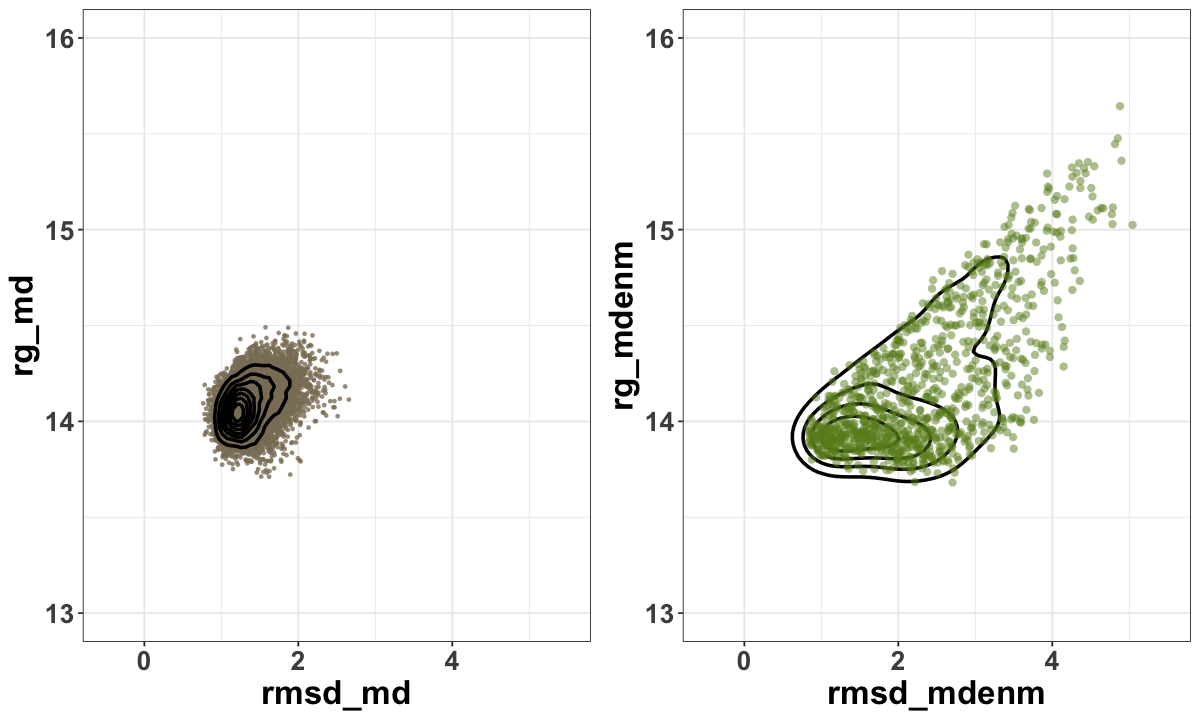

In [13]:
global_size = 20
p1 <- ggplot() +

 stat_density_2d(aes(x=rmsd_mdenm, y=rg_mdenm), linewidth=1, 
                  contour_var = "ndensity", h=NULL,color="black", bins=5) +
 geom_point(aes(x=rmsd_mdenm, y=rg_mdenm), color="olivedrab4", size=2, shape=16, alpha=0.5) +
 xlim (-0.5, 5.5) + ylim(13,16) + theme_bw() +  theme(text = element_text(size=global_size, face = "bold"))

p2 <- ggplot() +
 geom_point(aes(x=rmsd_md, y=rg_md), 
            color="wheat4", size=1, shape=16, alpha=0.8) +
stat_density_2d(aes(x=rmsd_md, y=rg_md), linewidth=1,contour_var = "ndensity", h=NULL,color="black", bins=8) +
 xlim (-0.5, 5.5) + ylim(13,16) + theme_bw() +  theme(text = element_text(size=global_size, face = "bold"))

library(gridExtra)
options(repr.plot.width=10, repr.plot.height=6)
grid.arrange(p2, p1, nrow = 1) 

### Data from the original MDexciter paper  <https://doi.org/10.1021/acs.jctc.5b00003>

<img src="rmsd_rg_mdexciter_paper.jpeg" width="600" align='center'>

In [14]:
# Concatenating the trajectories (1us standard MD + MDeNM + experimental ensemble)
traj <- rbind(md, mdenm, exp)

# Create a factor to color each trajectory
md_frames <- dim(md)[1]
mdenm_frames <- dim(mdenm)[1]
exp_frames <- dim(exp)[1]
grp_traj <- c(rep(1, md_frames), c(rep(3, mdenm_frames)), c(rep(2, exp_frames)))


In [15]:
#Fitting the trajectories to the reference structure
traj_fit <- fit.xyz(fixed = lyso_ca$xyz, mobile = traj)

Warning message in fit.xyz(fixed = lyso_ca$xyz, mobile = traj):
“No fitting indices provided, using the 129 non NA positions
”


In [16]:
# Calculating the PCA for the concatenated trajectory 
pca_all <- pca.xyz(traj_fit, use.svd = T)

In [17]:
pca_all


Call:
  pca.xyz(xyz = traj_fit, use.svd = T)

Class:
  pca

Number of eigenvalues:
  387

        Eigenvalue Variance Cumulative
   PC 1     50.541   25.399     25.399
   PC 2     30.218   15.186     40.584
   PC 3     24.259   12.191     52.775
   PC 4     10.671    5.362     58.138
   PC 5      6.912    3.474     61.612
   PC 6      5.763    2.896     64.508

   (Obtained from 11804 conformers with 387 xyz input values).

+ attr: L, U, z, au, sdev, mean, call

### Ploting the trajectories onto the PCs

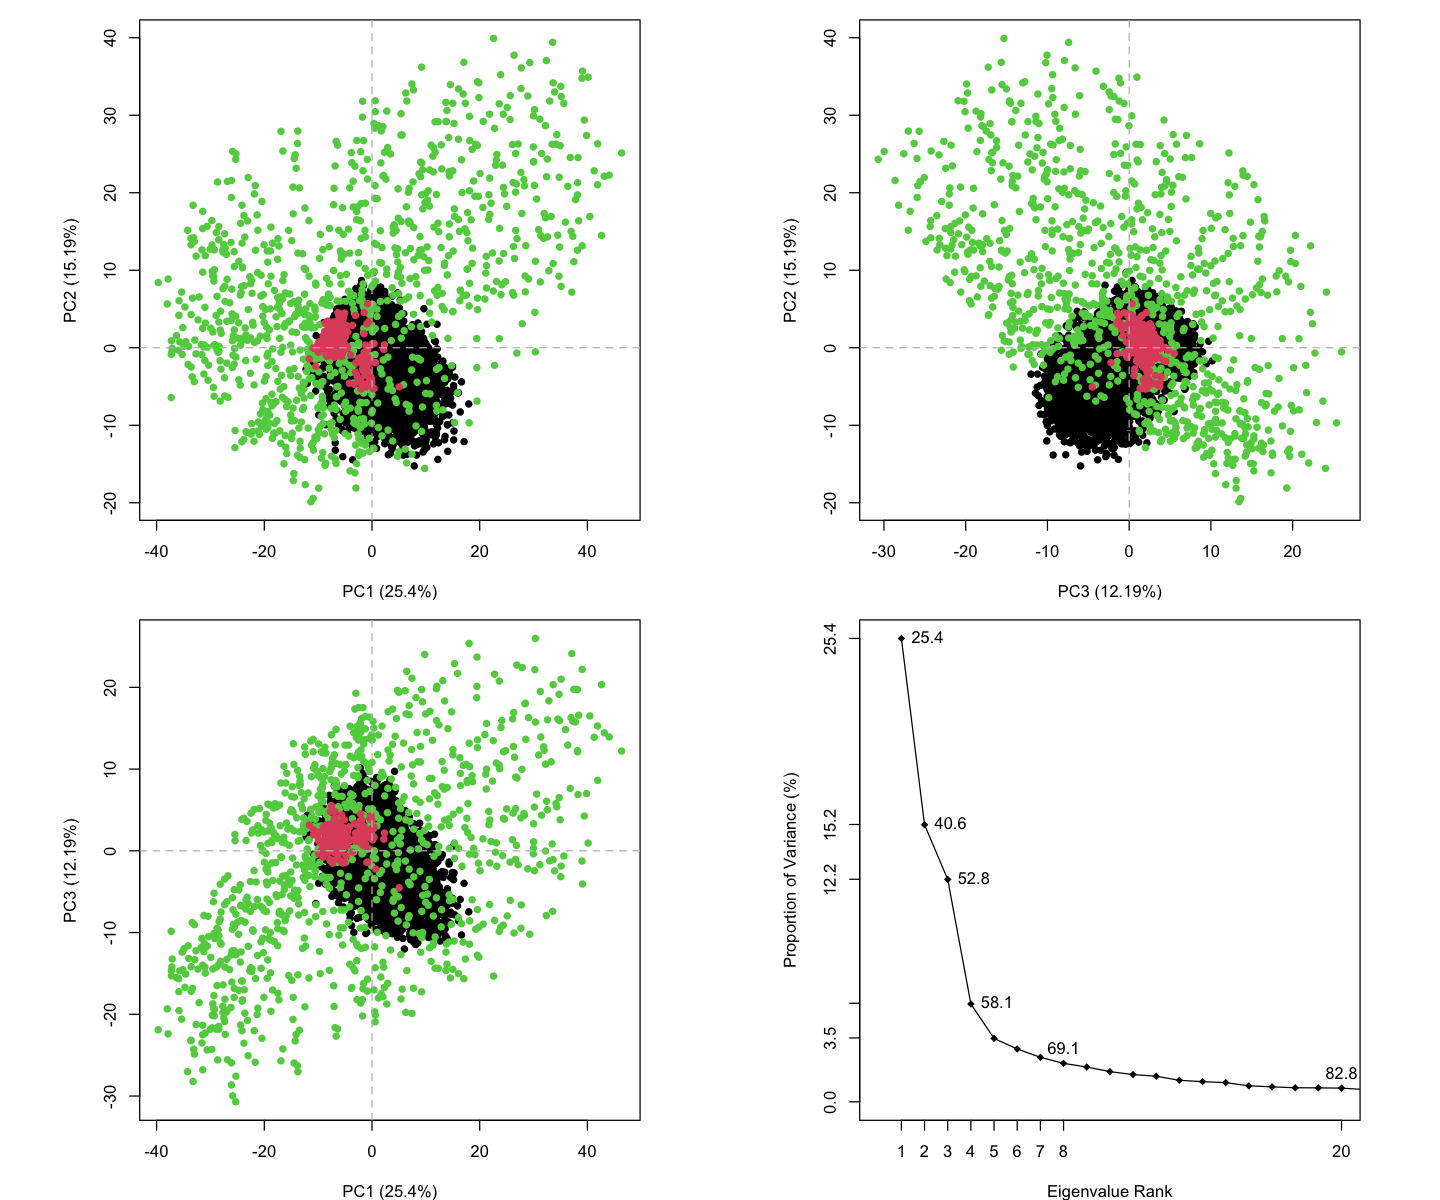

In [18]:
#Ploting the trajectories onto the PCs
# 1us MD - black
# MDeNM - green
# exp - Red

options(repr.plot.width=12, repr.plot.height=10)
plot.pca(pca_all, col=grp_traj)

### Comparing the PCs with the normal modes


In [19]:
# Comparing the PCs with the normal modes
rmsip <- rmsip(modes, pca_all)

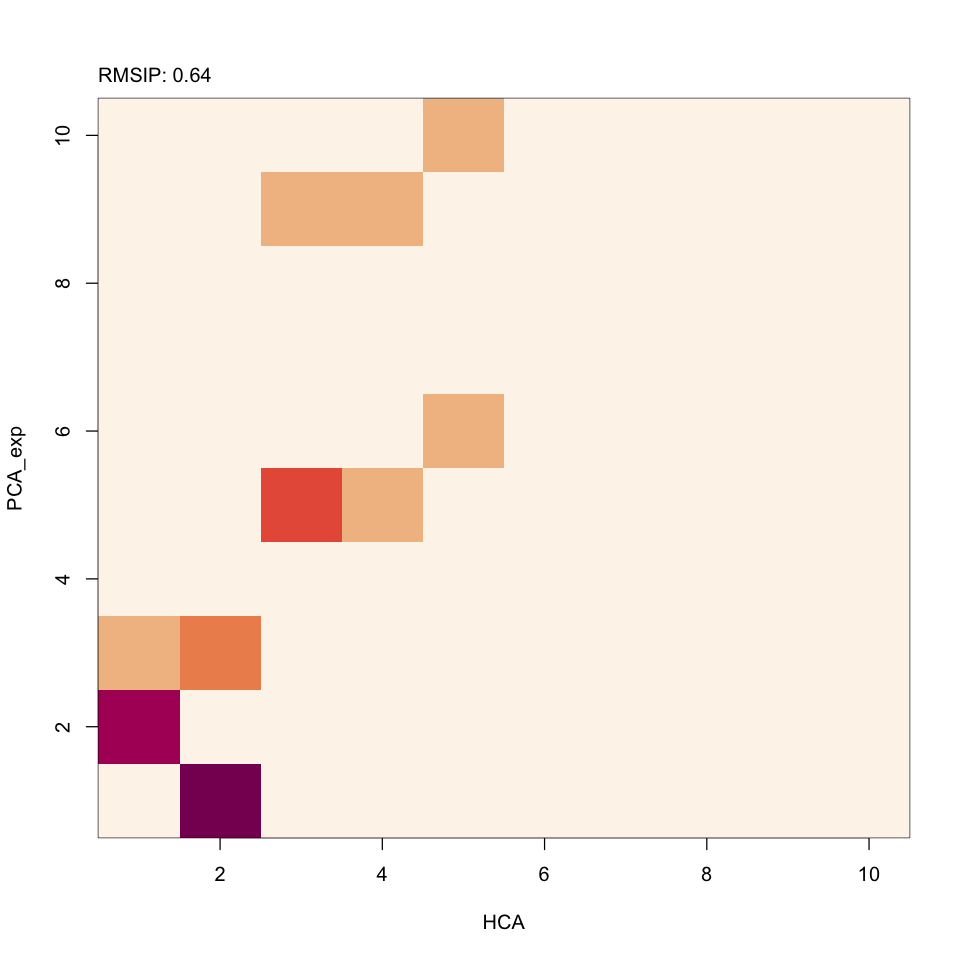

In [20]:
options(repr.plot.width=8, repr.plot.height=8)
plot(rmsip, xlab="HCA", ylab="PCA_exp", col=hcl.colors(10,"Rock", rev=T))

In [21]:
mktrj.nma(modes, mode=7, step=1, mag=120, file = "mdenm/mode_7.pdb")
mktrj.nma(modes, mode=8, step=1, mag=120, file = "mdenm/mode_8.pdb")


### Calcutating trajectories projections onto the mode 7 and 8

In [22]:
# Creating normal mode trajectories
mode7 <- read.pdb("mdenm/mode_7.pdb", multi = T)
mode8 <- read.pdb("mdenm/mode_8.pdb", multi = T)
#Concatenating trajs
modes_xyz <- rbind (mode7$xyz, mode8$xyz)
traj_teste <- rbind(md, mdenm, exp, modes_xyz)

In [23]:
#Fitting trajectories to the reference structure 
teste_fit <- fit.xyz(fixed = lyso_ca$xyz, mobile = traj_teste)

Warning message in fit.xyz(fixed = lyso_ca$xyz, mobile = traj_teste):
“No fitting indices provided, using the 129 non NA positions
”


In [24]:
# Performing PCA
pca_teste <- pca.xyz(teste_fit, use.svd = T)

In [25]:
modes_frames <- dim(modes_xyz)[1]

In [26]:
#Creating data frames to plot the normal mode projections
grp_teste <- c(rep(1, md_frames), c(rep(3, mdenm_frames)), c(rep(2, exp_frames)), c(rep(4, modes_frames))) 
data <- data.frame(pca_teste$z, factor= c(rep("MD", md_frames), rep("MDENM", mdenm_frames),rep("exp", exp_frames), rep("modes", modes_frames)))
df_md <-data[data$factor == 'MD', ]
df_mdenm <-data[data$factor == 'MDENM', ]
df_exp <-data[data$factor == 'exp', ]

### Ploting the normal mode projection of each trajectory

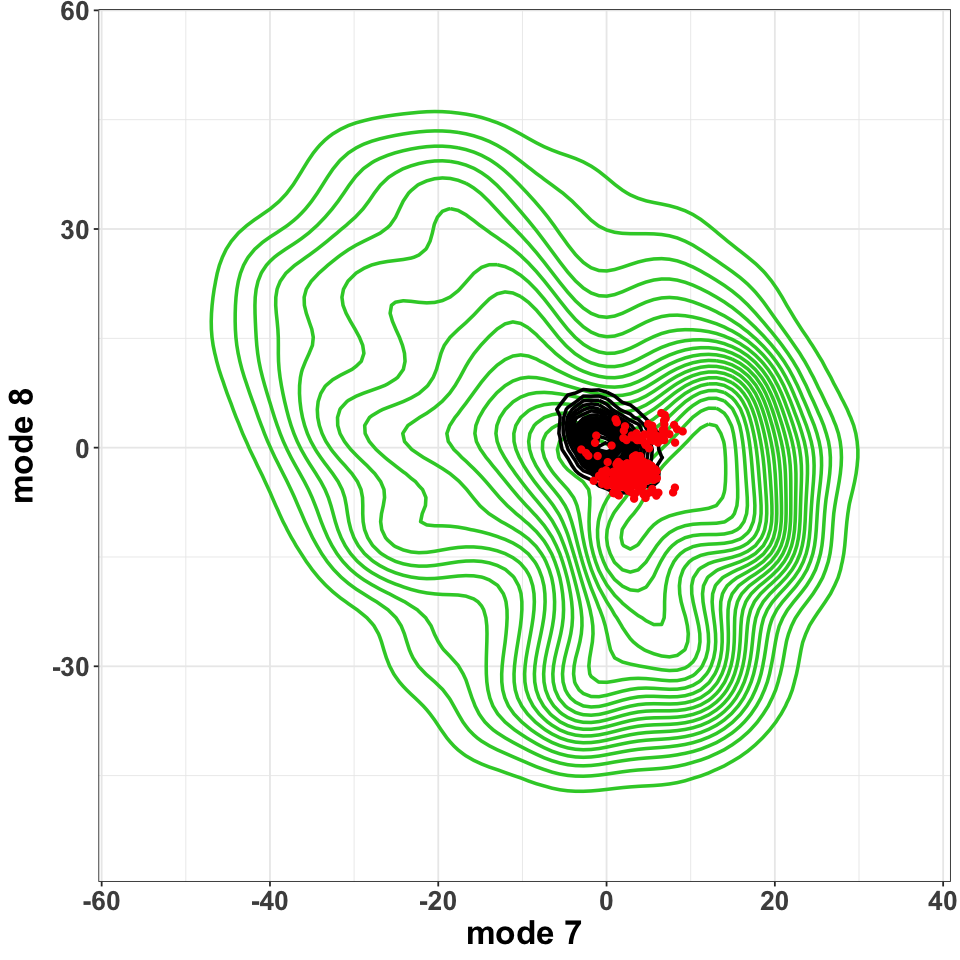

In [27]:
options(repr.plot.width=8, repr.plot.height=8)
l <- density(df_mdenm$X1)
m <- density(df_mdenm$X2)
ggplot() +
 stat_density_2d(aes(x=df_mdenm$X1, y=df_mdenm$X2), linewidth=1, contour_var = "ndensity", h=NULL,color="limegreen", bins=20) +
 #geom_point(aes(x=df_mdenm$X1, y=df_mdenm$X2), color="green", size=1, shape=16)   +

stat_density_2d(aes(x=df_md$X1, y=df_md$X2), linewidth=1, contour_var = "ndensity", h=NULL,color="black", bins=20) +
 geom_point(aes(x=df_exp$X1, y=df_exp$X2), color="red", size=2, shape=16)   +
xlab ("mode 7") + ylab("mode 8") + xlim(range(l$x)) + ylim(range(m$x)) +theme_bw() +  theme(text = element_text(size=global_size, face = "bold"))

### Density plots of normal mode projections from each trajectory

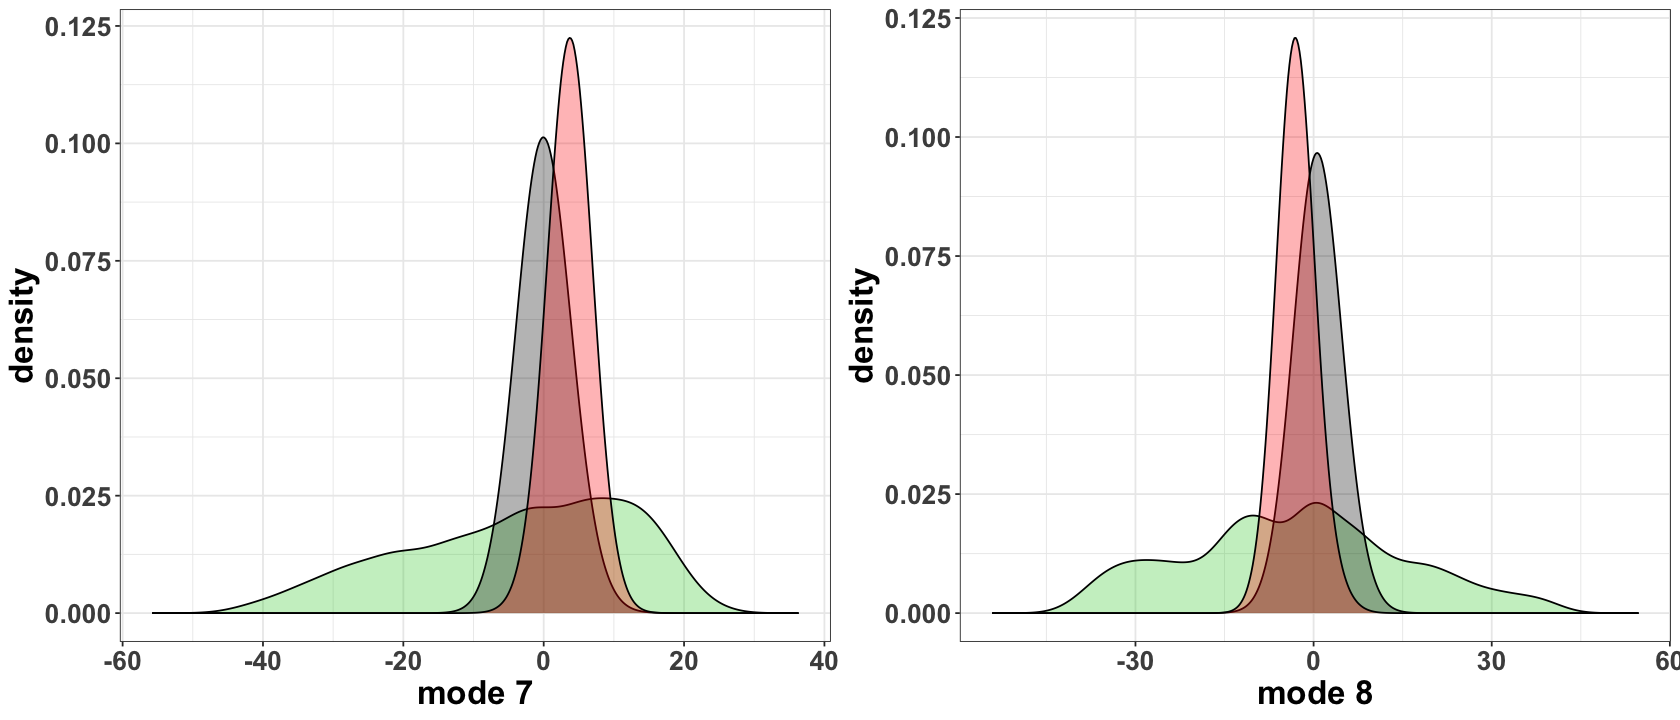

In [28]:
options(repr.plot.width=14, repr.plot.height=6)
l <- density(df_mdenm$X1)
p1 <- ggplot() +
 geom_density(aes(x=df_mdenm$X1), fill="limegreen", alpha=0.3, bw=3) +
 geom_density(aes(x=df_md$X1), fill="black", alpha=0.3, bw=3) +
 geom_density(aes(x=df_exp$X1), fill="red", alpha=0.3, bw=3) +
 xlim(range(l$x)) + theme_bw()  +  theme(text = element_text(size=global_size, face = "bold")) +
xlab("mode 7")

l <- density(df_mdenm$X2)
p2 <- ggplot() +
geom_density(aes(x=df_mdenm$X2), fill="limegreen", alpha=0.3, bw=3) +
geom_density(aes(x=df_md$X2), fill="black", alpha=0.3, bw=3) +
geom_density(aes(x=df_exp$X2), fill="red", alpha=0.3, bw=3) +
xlim(range(l$x)) + theme_bw() +  theme(text = element_text(size=global_size, face = "bold")) +
xlab("mode 8") 
grid.arrange(p1, p2, nrow = 1)

## Calculating the lysozime pseudo pincer angle

#### <span style="color: Olive;">The pincer angle is calculated from the centers of mass of the Cα atoms from three protein regions:</span>
 *  region 1 (in the α domain) spans residues 28–31 and 111–114;
 *  region 2 (in the hinge) spans residues 90–93;
 *  region 3 (in the β domain) spans residues 44–45 and 51–52.

Ref.:Characterization of the interdomain motions in hen lysozyme using residual dipolar couplings as replica-averaged structural restraints in molecular dynamics simulations. De Simone, Alfonso; Montalvao, Rinaldo W.; Dobson, Christopher M.; Vendruscolo, Michele Biochemistry (2013)

<https://doi.org/10.1021/bi4007513>

![image.png](lyso_pincer.jpeg)


### We developed a prody-based scrip (Python) to calculate the angle between the CoM of each domain

In [34]:
# Running the python script
system('python calc_pincer.py md')
system('python calc_pincer.py mdenm')
system('python calc_pincer.py exp')


In [30]:
# Parsing the calculated pincer angles
mdenm_pincer <- read.csv("pincer_mdenm.csv")
md_pincer <- read.csv("pincer_md.csv")
exp_pincer <- read.csv("pincer_exp.csv")

In [31]:
head(mdenm_pincer)

,X,angle
,<int>,<dbl>
1,0,65.04438
2,1,65.98839
3,2,69.17048
4,3,75.27668
5,4,80.16841
6,5,83.69778


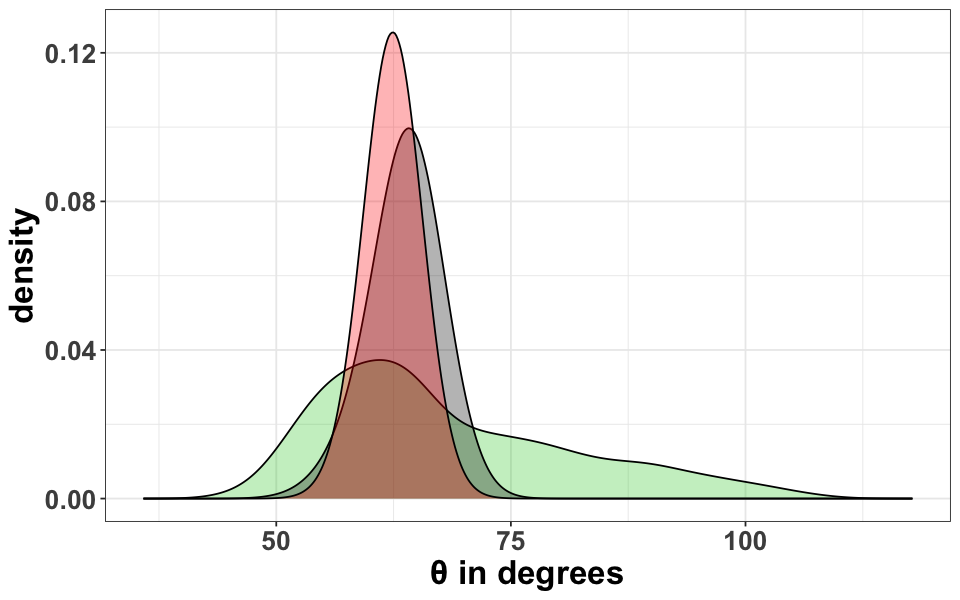

In [32]:
options(repr.plot.width=8, repr.plot.height=5)
l <- density(mdenm_pincer$angle)
p1 <- ggplot() +
 geom_density(aes(x=mdenm_pincer$angle), fill="limegreen", alpha=0.3, bw=3) +
                
geom_density(aes(x=md_pincer$angle), fill="black", alpha=0.3, bw=3) +
geom_density(aes(x=exp_pincer$angle), fill="red", alpha=0.3, bw=3) + theme_bw() +
xlim(range(l$x)) + 
xlab("θ in degrees") +  theme(text = element_text(size=global_size, face = "bold"))
p1

<img src="pincer_angle_paper.jpeg" width="450" align='center'>